# How to Run Experiments with the Experiment Framework

This notebook demonstrates how to use the `Experiment` class to benchmark
shape matching methods on datasets.

We will:
1. Load the FAUST test set using `MeshDataset`
2. Create shape pairs using `PairsDataset`
3. Run a single experiment with `Experiment`
4. Compare multiple methods with `ExperimentSuite`
5. Analyze and save results

**Note:** For advanced features like grid search and configuration presets, see:
- [22_configuration_presets.ipynb](./22_configuration_presets.ipynb)
- [23_systematic_experiments.ipynb](./23_systematic_experiments.ipynb)

## Setup

In [1]:
from geomfum.dataset.torch import MeshDataset, PairsDataset
from geomfum.experiment import Experiment, ExperimentConfig, ExperimentSuite
from geomfum.matcher import FeatureMatcher, FunctionalMapMatcher

## Load the FAUST Test Set

The FAUST dataset contains registered human body meshes. We load the test set
with spectral decomposition pre-computed (needed for functional maps).

In [2]:
# Path to the FAUST test set
dataset_dir = "../../../datasets/faust/test_set"

# Load meshes with spectral features
# spectral=True computes Laplacian eigenfunctions
# distances=True loads/computes geodesic distance matrices (for evaluation)
mesh_dataset = MeshDataset(
    dataset_dir=dataset_dir,
    spectral=True,
    distances=True,
    correspondences=True,  # FAUST has identity correspondences (same topology)
    k=30,  # Number of eigenfunctions
)

print(f"Loaded {len(mesh_dataset)} meshes")

Loaded 20 meshes


## Create Shape Pairs

We create pairs of shapes to match. For a quick demo, we use a small subset.

In [3]:
# Create pairs dataset
# pair_mode="all" creates all n*(n-1) pairs
# Use pairs_ratio to sample a subset for faster experimentation
pairs_dataset = PairsDataset(
    dataset=mesh_dataset,
    pair_mode="random",
    pairs_ratio=0.1,  # Use 5% of possible pairs for demo
)

print(f"Created {len(pairs_dataset)} pairs")

Created 2 pairs


## Single Experiment with Experiment

The `Experiment` class runs a single method on a dataset and evaluates it.

In [4]:
matcher = FunctionalMapMatcher()

### Run the Experiment

The `Experiment` class handles:
- Iterating over all pairs
- Computing correspondences with the matcher
- Evaluating metrics (geodesic error, coverage, etc.)
- Aggregating results

In [5]:
# Configure the experiment
exp_config = ExperimentConfig(
    name="FAUST_FunctionalMap",
    bidirectional=False,  # Only compute A->B direction
    progress_bar=True,
)

# Create and run the experiment
experiment = Experiment(
    method=matcher,
    dataset=pairs_dataset,
    config=exp_config,
)

result = experiment.run()

Running FAUST_FunctionalMap:   0%|          | 0/2 [00:00<?, ?pair/s]

Running FAUST_FunctionalMap: 100%|██████████| 2/2 [00:08<00:00,  4.29s/pair, geo_err=0.1485]
INFO:root:Experiment 'FAUST_FunctionalMap' completed:
INFO:root:  dirichlet_energy: 0.0093
INFO:root:  dirichlet_energy_std: 0.0007
INFO:root:  euclidean_error: 0.1134
INFO:root:  euclidean_error_std: 0.0581
INFO:root:  coverage_count: 0.2440
INFO:root:  coverage_count_std: 0.0052
INFO:root:  coverage: 0.3094
INFO:root:  coverage_std: 0.0004
INFO:root:  geodesic_error: 0.1485
INFO:root:  geodesic_error_std: 0.0949


### Analyze Results

In [6]:
# View aggregated metrics
print("=" * 50)
print("Aggregated Metrics:")
print("=" * 50)
for metric, value in result.metrics.items():
    if not metric.endswith("_std"):
        std = result.metrics.get(f"{metric}_std", 0)
        print(f"{metric}: {value:.4f} ± {std:.4f}")

Aggregated Metrics:
dirichlet_energy: 0.0093 ± 0.0007
euclidean_error: 0.1134 ± 0.0581
coverage_count: 0.2440 ± 0.0052
coverage: 0.3094 ± 0.0004
geodesic_error: 0.1485 ± 0.0949


In [7]:
# View per-pair metrics
import numpy as np

geodesic_errors = [
    m["geodesic_error"] for m in result.per_pair_metrics if "geodesic_error" in m
]

print("\nGeodesic Error Statistics:")
print(f"  Min:    {np.min(geodesic_errors):.4f}")
print(f"  Max:    {np.max(geodesic_errors):.4f}")
print(f"  Median: {np.median(geodesic_errors):.4f}")


Geodesic Error Statistics:
  Min:    0.0536
  Max:    0.2434
  Median: 0.1485


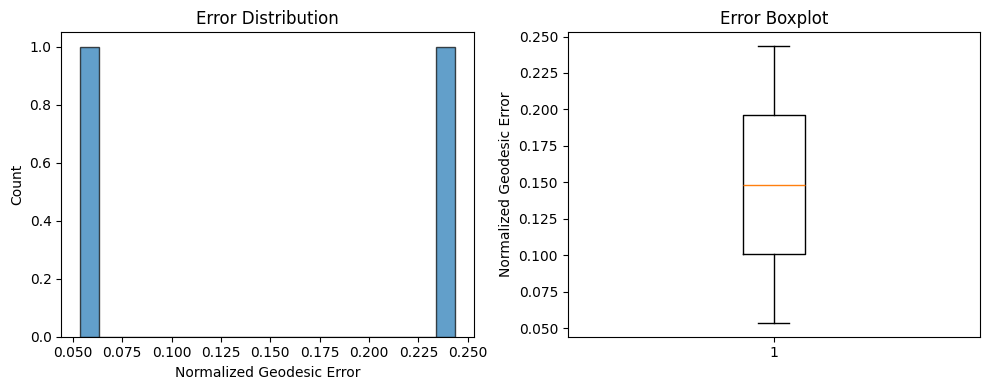

In [8]:
# Plot error distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(geodesic_errors, bins=20, edgecolor="black", alpha=0.7)
plt.xlabel("Normalized Geodesic Error")
plt.ylabel("Count")
plt.title("Error Distribution")

plt.subplot(1, 2, 2)
plt.boxplot(geodesic_errors)
plt.ylabel("Normalized Geodesic Error")
plt.title("Error Boxplot")

plt.tight_layout()
plt.show()

### Save Results

You can save the results to a JSON file for later analysis.

In [9]:
# Save results
# result.save("faust_fmatcher_results.json")

# Load results later
# from geomfum.experiment import ExperimentResult
# loaded_result = ExperimentResult.load("faust_fmatcher_results.json")

## Compare Multiple Methods with ExperimentSuite

The `ExperimentSuite` class makes it easy to compare multiple methods side-by-side.

In [10]:
# Define methods to compare
methods = {
    "FunctionalMap": FunctionalMapMatcher(),
    "Feature": FeatureMatcher(),
}

# Create and run suite
suite = ExperimentSuite(methods, pairs_dataset)
all_results = suite.run()

INFO:root:Running experiment: FunctionalMap
Running FunctionalMap: 100%|██████████| 2/2 [00:06<00:00,  3.20s/pair, geo_err=0.1485]
INFO:root:Experiment 'FunctionalMap' completed:
INFO:root:  dirichlet_energy: 0.0093
INFO:root:  dirichlet_energy_std: 0.0007
INFO:root:  euclidean_error: 0.1134
INFO:root:  euclidean_error_std: 0.0581
INFO:root:  coverage_count: 0.2440
INFO:root:  coverage_count_std: 0.0052
INFO:root:  coverage: 0.3094
INFO:root:  coverage_std: 0.0004
INFO:root:  geodesic_error: 0.1485
INFO:root:  geodesic_error_std: 0.0949
INFO:root:Running experiment: Feature
Running Feature: 100%|██████████| 2/2 [00:07<00:00,  3.55s/pair, geo_err=0.1488]
INFO:root:Experiment 'Feature' completed:
INFO:root:  dirichlet_energy: 0.0199
INFO:root:  dirichlet_energy_std: 0.0004
INFO:root:  euclidean_error: 0.1204
INFO:root:  euclidean_error_std: 0.0069
INFO:root:  coverage_count: 0.1867
INFO:root:  coverage_count_std: 0.0069
INFO:root:  coverage: 0.2113
INFO:root:  coverage_std: 0.0098
INFO:r

In [11]:
# Print comparison table
suite.print_comparison(metrics=["geodesic_error", "coverage"])

Method               | geodesic_error  | coverage       
--------------------------------------------------------
FunctionalMap        | 0.1485±0.0949 | 0.3094±0.0004
Feature              | 0.1488±0.0282 | 0.2113±0.0098


In [12]:
# Save all results
# suite.save_all("results/")

# Experiment of Faust

In [15]:
from geomfum.dataset.torch import MeshDataset, PairsDataset
from geomfum.descriptor.pipeline import (
    ArangeSubsampler,
    DescriptorPipeline,
    L2InnerNormalizer,
)
from geomfum.descriptor.spectral import (
    HeatKernelSignature,
    LandmarkHeatKernelSignature,
    LandmarkWaveKernelSignature,
    WaveKernelSignature,
)
from geomfum.experiment import ExperimentSuite
from geomfum.matcher import FeatureMatcher, FunctionalMapMatcher
from geomfum.refine import (
    CorrespondenceRefinementPipeline,
    RefinementPipeline,
    ZoomOut,
    ZoomOutCorrespondenceRefiner,
)

# Load dataset
dataset_dir = "../../../datasets/faust/test_set"
mesh_dataset = MeshDataset(
    dataset_dir=dataset_dir,
    spectral=True,
    distances=True,
    correspondences=True,
    landmark_indices=([412, 5891, 6593, 3323, 2119]),
    k=200,  # Need more eigenfunctions for ZoomOut
)

pairs_dataset = PairsDataset(
    dataset=mesh_dataset,
    pair_mode="all",
    pairs_ratio=1,
)

print(f"Loaded {len(mesh_dataset)} meshes, {len(pairs_dataset)} pairs")

# Common parameters
n_domain = 200
k = 200

# Define methods
methods = {
    # 1) FeatureMatcher with HKS only
    "Feature_HKS": FeatureMatcher(
        descriptor_pipeline=DescriptorPipeline(
            [
                HeatKernelSignature(n_domain=n_domain, k=k),
                ArangeSubsampler(subsample_step=10),
                L2InnerNormalizer(),
            ]
        )
    ),
    # 2) FeatureMatcher with WKS + LandmarkWKS
    "Feature_WKS+LmWKS": FeatureMatcher(
        descriptor_pipeline=DescriptorPipeline(
            [
                WaveKernelSignature(n_domain=n_domain, k=k),
                LandmarkWaveKernelSignature(n_domain=n_domain, k=k),
                ArangeSubsampler(subsample_step=10),
                L2InnerNormalizer(),
            ]
        )
    ),
    # 3) FunctionalMapMatcher with WKS + LandmarkWKS
    "FMap_WKS+LmWKS": FunctionalMapMatcher(
        fmap_size=20,
        descriptor_pipeline=DescriptorPipeline(
            [
                WaveKernelSignature(n_domain=n_domain, k=k),
                LandmarkWaveKernelSignature(n_domain=n_domain, k=k),
                ArangeSubsampler(subsample_step=10),
                L2InnerNormalizer(),
            ]
        ),
    ),
    # 4) FeatureMatcher with WKS + LandmarkWKS + ZoomOut
    "Feature_WKS+LmWKS+ZO": FeatureMatcher(
        descriptor_pipeline=DescriptorPipeline(
            [
                WaveKernelSignature(n_domain=n_domain, k=k),
                LandmarkWaveKernelSignature(n_domain=n_domain, k=k),
                ArangeSubsampler(subsample_step=10),
                L2InnerNormalizer(),
            ]
        ),
        refiner=CorrespondenceRefinementPipeline(
            [
                ZoomOutCorrespondenceRefiner(nit=20, step=5, fmap_init_size=20),
            ]
        ),
    ),
    # 5) FunctionalMapMatcher with WKS + LandmarkWKS + ZoomOut
    "FMap_WKS+LmWKS+ZO": FunctionalMapMatcher(
        fmap_size=20,
        descriptor_pipeline=DescriptorPipeline(
            [
                WaveKernelSignature(n_domain=n_domain, k=k),
                LandmarkWaveKernelSignature(n_domain=n_domain, k=k),
                ArangeSubsampler(subsample_step=10),
                L2InnerNormalizer(),
            ]
        ),
        refiner=RefinementPipeline(
            [
                ZoomOut(nit=20, step=5),
            ]
        ),
    ),
}

# Run comparison
suite = ExperimentSuite(methods, pairs_dataset)
results = suite.run()

# Print comparison table
suite.print_comparison(metrics=["geodesic_error", "coverage", "dirichlet_energy"])


INFO:root:Running experiment: Feature_HKS


Loaded 20 meshes, 380 pairs


Running Feature_HKS:   7%|▋         | 27/380 [01:31<19:59,  3.40s/pair, geo_err=0.1619]


KeyboardInterrupt: 

## Next Steps

For more advanced experimentation patterns:

- **[22_configuration_presets.ipynb](./22_configuration_presets.ipynb)** - Using preset configurations
- **[23_systematic_experiments.ipynb](./23_systematic_experiments.ipynb)** - Grid search and parameter exploration
- **[19_matcher.ipynb](./19_matcher.ipynb)** - Customizing matcher configurations